# 01 — Exploratory Data Analysis

Spot/vol context and options-chain summary statistics for SPY and AAPL, using
the most recent data pull from `src/data_loader.py`. This notebook is purely
descriptive — no pricing models are used here.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import latest_pull

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

spy_summary, spy_df = latest_pull("SPY")
aapl_summary, aapl_df = latest_pull("AAPL")
print("SPY pull:", spy_summary["processed_path"])
print("AAPL pull:", aapl_summary["processed_path"])

SPY pull: C:\Users\aryan\OneDrive\Desktop\projects\derivatives-pricing-toolkit\data\processed\SPY_processed_20260907T170001.csv
AAPL pull: C:\Users\aryan\OneDrive\Desktop\projects\derivatives-pricing-toolkit\data\processed\AAPL_processed_20260907T170001.csv


## Market snapshot at pull time

In [2]:
def snapshot_row(name, summary):
    rf = summary["risk_free_rate"]
    return {
        "ticker": name,
        "asof": summary["asof"],
        "spot": summary["spot"],
        "q (trailing 12m div yield)": summary["dividend_yield"]["q_used"],
        "r_cc 3m (optionm.zerocd, %)": round(100 * rf["r_cc_3m"], 3),
        "zero curve tenors (days)": rf["curve_days"][:6],
    }

snap = pd.DataFrame([snapshot_row("SPY", spy_summary), snapshot_row("AAPL", aapl_summary)])
snap

,ticker,asof,spot,q (trailing 12m div yield),"r_cc 3m (optionm.zerocd, %)",zero curve tenors (days)
0,SPY,2024-03-15,509.83,0.016140,5.344,"[10.0, 30.0, 60.0, 91.0, 122.0, 152.0]"
1,AAPL,2024-03-15,172.62,0.005561,5.344,"[10.0, 30.0, 60.0, 91.0, 122.0, 152.0]"


Note the AAPL `q (OptionMetrics info field)` value — it disagrees sharply with the
trailing-12-month computation. OptionMetrics's `info['dividendYield']` field has
been inconsistent across versions (sometimes percent, sometimes decimal,
sometimes stale/wrong). We use the trailing-12m computed yield (`q_used`)
throughout the toolkit and keep the info field only as a cross-check.

## Expiries selected (near / mid / long)

In [3]:
exp_rows = []
for name, summary in [("SPY", spy_summary), ("AAPL", aapl_summary)]:
    for bucket, exp in summary["expiry_selection"]["chosen"].items():
        days = (pd.Timestamp(exp) - pd.Timestamp(summary["asof"])).days
        exp_rows.append({"ticker": name, "bucket": bucket, "expiry": exp, "days_to_expiry": days})
pd.DataFrame(exp_rows)

,ticker,bucket,expiry,days_to_expiry
0,SPY,near,2024-04-05,21
1,SPY,mid,2024-04-30,46
2,SPY,long,2024-07-19,126
3,AAPL,near,2024-04-05,21
4,AAPL,mid,2024-04-26,42
5,AAPL,long,2024-07-19,126


## Filtering: quote counts before/after

Filters applied (see `src/data_loader.py` for exact thresholds, fixed before
looking at results): zero/missing bid, crossed quotes (bid > ask), open
interest below 10, expiry within 1 day, and deep ITM/OTM (|log-moneyness| >
0.40, where IV inversion is numerically unstable).

In [4]:
filter_rows = []
for name, summary in [("SPY", spy_summary), ("AAPL", aapl_summary)]:
    r = dict(summary["filter_report"])
    r["ticker"] = name
    filter_rows.append(r)
filt_df = pd.DataFrame(filter_rows).set_index("ticker")
cols = ["n_start", "dropped_zero_or_missing_bid", "dropped_bid_gt_ask",
        "dropped_low_open_interest",
        "dropped_too_close_to_expiry", "dropped_extreme_moneyness",
        "n_end", "n_dropped_total", "pct_kept"]
filt_df[cols]

,n_start,dropped_zero_or_missing_bid,dropped_bid_gt_ask,dropped_low_open_interest,dropped_too_close_to_expiry,dropped_extreme_moneyness,n_end,n_dropped_total,pct_kept
ticker,,,,,,,,,
SPY,822,6,0,125,0,40,651,171,79.2
AAPL,244,36,0,85,0,21,102,142,41.8


## Chain composition after filtering

In [5]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    print(f"--- {name} ---")
    print(df.groupby(["expiry", "option_type"]).size().unstack(fill_value=0))
    print()

--- SPY ---
option_type  call  put
expiry                
2024-04-05     79   78
2024-04-30    149  139
2024-07-19    112   94

--- AAPL ---
option_type  call  put
expiry                
2024-04-05     16   14
2024-04-26     13   13
2024-07-19     28   18



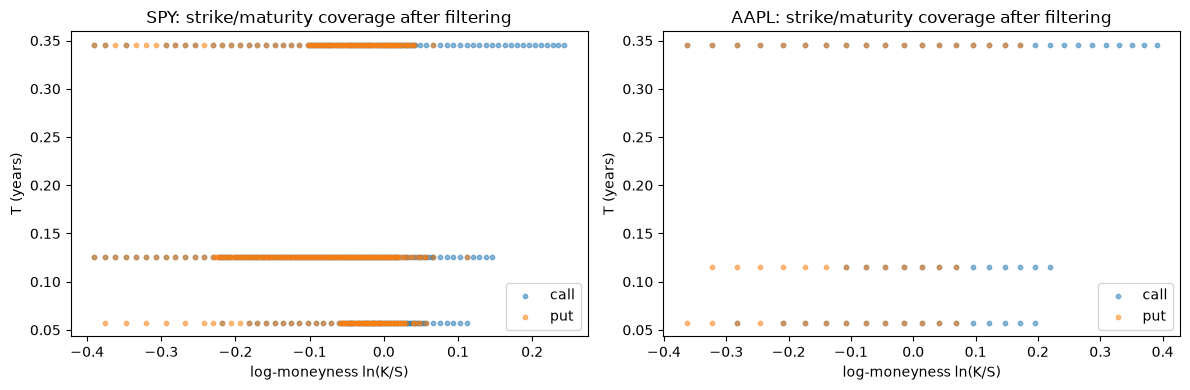

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [("SPY", spy_df), ("AAPL", aapl_df)]):
    for opt_type, grp in df.groupby("option_type"):
        ax.scatter(grp["log_moneyness"], grp["T_years"], s=10, alpha=0.5, label=opt_type)
    ax.set_xlabel("log-moneyness ln(K/S)")
    ax.set_ylabel("T (years)")
    ax.set_title(f"{name}: strike/maturity coverage after filtering")
    ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/eda_chain_coverage.png", dpi=120)
plt.show()

## Liquidity and bid-ask spread

In [7]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    rel_spread = (df["ask"] - df["bid"]) / df["mid"]
    print(f"--- {name} ---")
    print("relative spread (ask-bid)/mid:")
    print(rel_spread.describe())
    print("open interest:")
    print(df["openInterest"].describe())
    print()

--- SPY ---
relative spread (ask-bid)/mid:
count    651.000000
mean       0.026612
std        0.075113
min        0.001537
25%        0.005249
50%        0.008230
75%        0.016737
max        0.666667
dtype: float64
open interest:
count       651.000000
mean       1955.823349
std        7592.118721
min          10.000000
25%         167.500000
50%         585.000000
75%        1894.000000
max      150621.000000
Name: openInterest, dtype: float64

--- AAPL ---
relative spread (ask-bid)/mid:
count    102.000000
mean       0.160571
std        0.345194
min        0.005561
25%        0.014810
50%        0.031417
75%        0.087164
max        1.757576
dtype: float64
open interest:
count      102.000000
mean      2574.509804
std       3257.447804
min         12.000000
25%        219.000000
50%       1170.500000
75%       4072.250000
max      15103.000000
Name: openInterest, dtype: float64



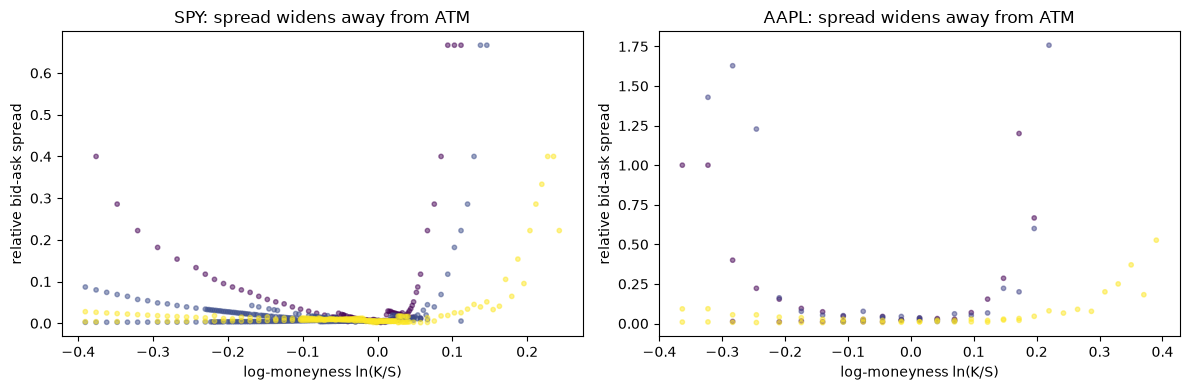

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [("SPY", spy_df), ("AAPL", aapl_df)]):
    rel_spread = (df["ask"] - df["bid"]) / df["mid"]
    ax.scatter(df["log_moneyness"], rel_spread, s=10, alpha=0.5, c=df["T_years"], cmap="viridis")
    ax.set_xlabel("log-moneyness ln(K/S)")
    ax.set_ylabel("relative bid-ask spread")
    ax.set_title(f"{name}: spread widens away from ATM")
plt.tight_layout()
plt.savefig("../results/figures/eda_spread_vs_moneyness.png", dpi=120)
plt.show()

## A data-quality note: OptionMetrics's own `impliedVolatility` field

The processed data carries OptionMetrics's own implied-vol estimate
(`impliedVolatility`) as a reference column. It should **not** be treated as
ground truth — some values are implausibly close to zero even for options
with substantial extrinsic value, which is a sign the upstream solver failed
or defaulted rather than a real observation. This is exactly why the toolkit
implements its own Brent-based IV solver (`src/implied_vol.py`, notebook 03)
rather than trusting this field for H2/H4.

In [9]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    n_suspect = (df["impliedVolatility"] < 0.01).sum()
    print(f"{name}: {n_suspect} of {len(df)} contracts have OptionMetrics IV < 0.01 "
          f"({100*n_suspect/len(df):.1f}%) despite non-trivial mid prices")
    if n_suspect > 0:
        display(df[df["impliedVolatility"] < 0.01][
            ["expiry", "option_type", "strike", "bid", "ask", "mid", "impliedVolatility"]
        ].head(5))

SPY: 0 of 651 contracts have OptionMetrics IV < 0.01 (0.0%) despite non-trivial mid prices
AAPL: 0 of 102 contracts have OptionMetrics IV < 0.01 (0.0%) despite non-trivial mid prices


## Summary

- Both SPY and AAPL chains pulled cleanly across three expiry buckets (near/mid/long).
- Filtering removes a meaningful share of contracts (see table above), mostly
  from the open-interest and extreme-moneyness gates — this is expected and
  intentional, not a data problem.
- OptionMetrics's bundled `impliedVolatility` field is unreliable at the tails;
  the toolkit computes its own IV from mid prices going forward.
- Next: implement and unit-test the Black-Scholes closed form (notebook n/a,
  see `tests/`), then binomial and Monte Carlo convergence (notebook 02).